# **Procesamiento de Lenguaje Natural**: modelado de temas (Topic Modelling) con Latent Dirichlet Allocation (LDA)

**Angel Navia Vázquez, Pablo Martínez Olmos**

  * 1.1 (January 2026) Revised and updated version

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='http://www.tsc.uc3m.es/~navia/figures/logo_uc3m_foot.jpg' width=400 />

# 1 - Modelado de temas o "Topic Modelling" (TM)

El **modelado de temas** (ing. "**Topic Modelling, TM**") es un método **no supervisado** para la **caracterización de textos**. Se considera una **extensión probabilística de LSA** (Latent Semantic Analysis), garantizando que obtenemos representaciones de los textos en función de **temas**,  siempre con **ponderaciones positivas**.

**TM** es útil para **analizar automáticamente** grandes colecciones de textos. Por ejemplo, permite:

- **descubrir las temáticas principales (temas)** presentes en una colección de textos.

- **asignar** cada documento a temas (cada documento tendrá un **peso de pertenencia a cada tema**). Dicho de otro modo, **cada documento se puede interpretar como una suma ponderada de temas**. Por tanto, no hay una asignación exclusiva de cada documento a cada tema.  

- usar esta **organización en temas** para **visualizar, agrupar, navegar o localizar** documentos.

# 2 - Latent Dirichlet Allocation (LDA)

La principal técnica para el modelado de tópicos se conoce como "**Latent Dirichlet Allocation**" o **LDA**. Es un **modelo generativo probabilístico para textos**, incialmente propuesta por [David Blei](http://www.cs.columbia.edu/~blei/papers/Blei2012.pdf), que permite explicar un conjunto de **observaciones** (**palabras en documentos**) mediante un conjunto de **modelos no observados** (**temas**).

La siguiente figura resume los principales **elementos del LDA**:


<img src='http://www.tsc.uc3m.es/~navia/figures/LDA1.png' width=800 />


- Un **documento** está descrito por las palabras que lo componen (esta mezcla es **CONOCIDA**).

- Cada **tema ("topic")** está descrito por una **colección ponderada de palabras** (esta mezcla es **inicialmente DESCONOCIDA** y **común para todos los documentos**).

- Queremos modelar cada **documento** como una **suma ponderada de temas** (esta mezcla es **inicialmente DESCONOCIDA**). Se supone que los documentos con temáticas similares utilizarán un grupo similar de palabras y por tanto compartirán los mismos temas.

# 3 - Representación de modelos estadísticos mediante modelos gráficos

Se puede considerar **LDA** como un **modelo estadístico** de textos en el que se combinan diferentes **variables aleatorias**, como veremos a continuación.

Los **modelos gráficos** proporcionan una **metodología general para caracterizar y visualizar modelos estadísticos** con una gran cantidad de variables aleatorias. En concreto, permiten manipular **distribuciones de probabilidad conjuntas**, incluyendo modelos jerárquicos de **variables latentes**. Cuando se trata de un grafo dirigido, como en este caso, se denominan **Redes Bayesianas**. También se utilizan modelos gráficos para la representación de redes profundas (**Deep Learning**).

No pretendemos aquí alcanzar un conocimiento profundo de los modelos gráficos, pero sí **entender los principios básicos** y utilizarlos para entender mejor el funcionamiento de LDA.




Veamos primero un ejemplo sencillo:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/graph_model1.png' width=600 />
</center>

En la figura de la izquierda estamos usando la **"notación de placa" (plate notation)**, y en la figura de la derecha el modelo expandido mostrando todas las variables implicadas.

El modelo tiene $N$ variables $Z_i$, independientes entre sí, pero todas ellas condicionadas a otra v.a. $\theta$, común para todas pero desconocida (latente), que gobierna el comportamiento de las variables $Z_i$. Es decir, estamos modelando $N$ distribuciones $p(Z_n|\theta)$.




**Ejemplo práctico**:

Queremos evaluar la calidad de un hotel ($\theta$, oculta) a partir de las opiniones de los clientes ($Z_i$, $N$ observaciones independientes disponibles).

- Si los comentarios ($Z_i$) son **binarios** (Me gustó / no me gustó, 0/1) $\theta$ representa un único número entre 0 y 1 (por ejemplo, 0.85), que es la probabilidad de que a un cliente le guste el hotel.

- Si los comentarios ($Z_i$) son **categóricos** (Escalas de estrellas: {1, 2, 3, 4, 5}), $\theta$ ya no es un solo número, sino un vector de probabilidades para cada una de las opciones (por ejemplo $\theta = [0.1, 0.1, 0.1, 0.2, 0.5]$ para las 5 opciones). La suma de todos los elementos de $\theta$ debe ser 1.

Veamos ahora cómo sería la **relación entre variables aleatorias** en el caso **LDA**. Entran en juego un mayor número de variables, pero el modelo gráfico nos permite **visualizar y comprender la interrelación** entre las mismas:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/graph_model_lda_v2.png' width=800 />
</center>




Comencemos **identificando los principales elementos del modelo**: variables aleatorias asociadas a **palabras**, **documentos** y **temas**:

- La placa gris de la derecha ($K$ elementos) representa los **temas** (topics) del modelo, **$\vec{\varphi}_k$ representa la distribución de palabras de cada tema**. $\vec{\beta}$ es un vector externo del tamaño del vocabulario, que controla cómo se mezclan las palabras dentro de los temas, es decir, decide la "pureza" de cada tema al indicar si se define con pocas palabras ($\beta_i \to 0$, modelo "sparse") o si es muy difuso ($\beta_i > 1$).

- La placa amarilla grande de la izquierda (M elementos) representa los **documentos** (corpus de M documentos). Cada documento se caracteriza por **$\vec{\theta}_m$, su propia proporción de temas**. El parámetro externo $\vec{\alpha}$ es un vector externo de tamaño $K$ (número de temas), controla la mezcla de temas en cada documento, es decir, decide si un documento suele hablar de un solo tema ($\alpha_i \to 0$) o si mezcla muchos ($\alpha_i > 1$).

- La placa naranja en el centro ($N_m$ elementos) representa las **palabras de cada documento**. El documento "m" tiene "$N_m$" palabras. $z_{m,n}$ representa la asignación de tema a la palabra $w_{m,n}$.


Si suponemos conocidas todas las variables aleatorias, podríamos  interpretar este modelo en **modo generativo**, es decir, como si fuera un "**escritor automático**", que seguiría los siguientes pasos para escribir el documento "m":

- $\vec{\alpha}$ y $\vec{\beta}$ (Parámetros Dirichlet) son el "jefe externo", le indican al escritor el nivel de mezcla de temas que debe haber en cada documento, y el nivel de mezcla de palabras en cada tema, respectivamente.  

- $\vec{\theta}_m$ representa la mezcla de temas del documento "m" y se genera a partir del parámetro Dirichlet$^{(1)}$ $\vec{\alpha}$ ($\vec{\theta}_m  \sim \text{Dirichlet}(\vec{\alpha})$). Si por ejemplo hay dos temas (Política y Economía) y $\vec{\theta}_m = [0.8, 0.2]$, el documento "m" tendrá un 80% de Política y un 20% de Economía".

- $\vec{\varphi}_k$ representa el vocabulario más probable del tema "k" y se genera a partir del parámetro Dirichlet$^{(1)}$ $\vec{\beta}$ ($\vec{\varphi}_k  \sim \text{Dirichlet}(\vec{\beta})$). Por ejemplo, el tema "Política" tiene probabilidades altas para las palabras "voto", "ley" y "congreso".

- $z_{m,n}$ es la asignación de tema, $z_{m,n} \in \{1, 2, \dots, K\}$ a partir de $\vec{\theta}_m$, el vector de parámetros que define una distribución multinomial$^{(2)}$ y que representa la probabilidad de cada tema. Siguiendo el ejemplo anterior, el tema será Política un 80% de las veces y Economía un 20%.

- Para generar la palabra número "$n$" del documento "$m$" ($w_{m,n}$) el escritor elige primero el tema aleatoriamente usando $z_{m,n}$ ("para generar esta palabra, usaré el tema Política") y luego se obtiene aleatoriamente la palabra a partir del vocabulario del tema seleccionado en el paso anterior (Distribución Multinomial$^{(2)}$ con parámetro $\vec{\varphi_k}$).

$^{(1)}$ Una Distribución de [Dirichlet](https://es.wikipedia.org/wiki/Distribuci%C3%B3n_de_Dirichlet) devuelve un vector de probabilidades que suma exactamente 1.

$^{(2)}$ Una distribución [Multinomial](https://es.wikipedia.org/wiki/Distribuci%C3%B3n_multinomial) se puede interpretar como lanzar un dado en el que cada cara representa una opción, pero éstas no son equiprobables.


Si representamos el modelo gráfico anterior de forma expandida, observamos el **modelo LDA generativo** completo, que sería como sigue:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/ldagenerative.jpg' width=600 />
</center>



En el ejemplo generativo anterior usando el modelo LDA, se suponían conocidas todas las distribuciones y se usaba este modelo para generar textos. En el **caso más habitual de uso de LDA, todas las distribuciones son desconocidas, salvo la lista de palabras en cada documento** (nodo sombreado en el grafo). Por tanto, **a partir de el corpus disponible, se debe utilizar cualquier algoritmo de inferencia Bayesiana (Muestreo de Gibbs, Inferencia Variacional, etc.) a fin de estimar todos los parámetros libres**.

Es importante notar que **$\vec{\theta}_m$, la proporción de temas en cada documento** es una **representación vectorial del mismo que resume su información en un vector de dimensión $K$**, con valores positivos que suman 1). Este vector puede ser utilizado como **vector de características** para aplicar otros algoritmos de aprendizaje (búsqueda de vecinos más cercanos, clasificación de documentos, etc.).



El **entrenamiento LDA** pretende obtener la **distribución a posteriori de probabilidad** $\vec{\beta}_k$ de las palabras por cada tema, y la proporción de temas por documento $\vec{\theta}_m$, **dada una colección de documentos representados como un BoW** $\mathbf{X}= [\mathbf{x}_1,\ldots,\mathbf{x}_N]$:

$$ p(\vec{\beta}_k|\mathbf{X}), \qquad k=1, \ldots,K$$: dado un corpus, qué palabras definen mejor el tema $K$

$$ p(\vec{\theta}_m|\mathbf{X}), \qquad d=1,\ldots N$$: dado un corpus, qué mezcla de temas tiene el documento m.

Fijémonos que en este modelo estadístico, el **orden de las palabras no se tiene en cuenta**, al igual que en el BoW.

Para obtener muestras de las distribuciones a posteriori anteriores y **ajustar de este modo el modelo LDA**, se hace uso de las técnicas ya mencionadas: **Muestreo de Gibbs (Monte Carlo  basadas en cadenas de Markov) o Inferencia Variacional**, pero no entraremos en detalles de cómo se hacen dichas estimaciones.

<img src='http://www.tsc.uc3m.es/~navia/figures/LDA2.png' width=1000 />

# 4 - Preparando un corpus

En este notebook vamos a aplicar **LDA** sobre el dataset [**NeurIPS papers**](https://www.kaggle.com/rowhitswami/nips-papers-1987-2019-updated?select=papers.csv). Este dataset contiene los **títulos, abstract y texto de los artículos publicados en la conferencia** [**NeurIPS** (antes NIPS)](https://nips.cc/), la internacional conferencia más importante en aspecto relacionados con aprendizaje automático.

In [81]:
# Ejecutamos este código para preparar el contexto.
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
%matplotlib inline
# Figures plotted inside the notebook
%config InlineBackend.figure_format = 'retina'
# High quality figures
import matplotlib.pyplot as plt


In [82]:
# Estas librerías pueden dar problemas de dependencias, conviene instalarlas conjuntamente, para que pip resuelva correctamente las dependencias
!pip install --upgrade numpy pandas scipy gensim spacy nltk wordcloud pyldavis

In [83]:
import numpy as np
import scipy
import pandas as pd
import spacy
import gensim
import nltk
import wordcloud
import pyLDAvis

print(f"NumPy version: {np.__version__}")
print(f"Scipy version: {scipy.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Spacy version: {spacy.__version__}")
print(f"Gensim version: {gensim.__version__}")
print(f"NLTK version: {nltk.__version__}")
print(f"Wordcloud version: {wordcloud.__version__}")
print(f"pyLDAvis version: {pyLDAvis.__version__}")

# 2025
# NumPy version: 1.26.4
# Scipy version: 1.13.1
# Pandas version: 2.2.3
# Spacy version: 3.8.4
# Gensim version: 4.3.3
# NLTK version: 3.9.1

# 2026
# NumPy version: 2.4.2
# Scipy version: 1.17.0
# Pandas version: 3.0.1
# Spacy version: 3.8.11
# Gensim version: 4.4.0
# NLTK version: 3.9.2
# Wordcloud version: 1.9.6
# pyLDAvis version: 3.4.0

NumPy version: 2.2.6
Scipy version: 1.15.3
Pandas version: 2.3.3
Spacy version: 3.8.11
Gensim version: 4.4.0
NLTK version: 3.9.3
Wordcloud version: 1.9.6
pyLDAvis version: 3.4.0


In [84]:
papers = pd.read_csv('/Volumes/Extreme Pro Particion 1TB/ProcesadoLenguajeNatural/8_MaterialComplementario/papers.csv')

Nos vamos a quedar con los artículos más recientes, a partir de 2019.

In [85]:
recent_nips = papers.loc[papers['year']>=2019].copy()
print("Estamos usando {} artículos.".format(len(recent_nips)))

Estamos usando 1428 artículos.


In [86]:
recent_nips.head(10)

,source_id,year,title,abstract,full_text
8252,8547,2019,Compositional Plan Vectors,Autonomous agents situated in real-world envir...,Plan Arithmetic: Compositional Plan Vectors fo...
8253,610,2019,Learning to Propagate for Graph Meta-Learning,Meta-learning extracts the common knowledge fr...,Learning to Propagate for Graph Meta-Learning\...
8254,1164,2019,XNAS: Neural Architecture Search with Expert A...,This paper introduces a novel optimization met...,XNAS: Neural Architecture Search\n\nwith Exper...
8255,7845,2019,Multi-resolution Multi-task Gaussian Processes,We consider evidence integration from potentia...,Multi-resolution Multi-task Gaussian Processes...
8256,348,2019,Deep Equilibrium Models,We present a new approach to modeling sequenti...,Deep Equilibrium Models\n\nShaojie Bai\n\nJ. Z...
8257,2213,2019,Cross Attention Network for Few-shot Classific...,Few-shot classification aims to recognize unla...,Cross Attention Network for Few-shot Classiﬁca...
8258,1283,2019,Order Optimal One-Shot Distributed Learning,We consider distributed statistical optimizati...,Order Optimal One-Shot Distributed Learning\n\...
8259,8279,2019,Exact Gaussian Processes on a Million Data Points,Gaussian processes (GPs) are flexible non-para...,Exact Gaussian Processes on a Million Data Poi...
8260,1457,2019,Asymmetric Valleys: Beyond Sharp and Flat Loca...,Despite the non-convex nature of their loss fu...,Asymmetric Valleys: Beyond Sharp and Flat Loca...
8261,7779,2019,Calculating Optimistic Likelihoods Using (Geod...,A fundamental problem arising in many areas of...,Calculating Optimistic Likelihoods\n\nUsing (G...


Además, vamos a concatenar título y abstract para aplicar el procesado al texto total resultante:

In [87]:
recent_nips['Title_abstract'] = recent_nips['title'].map(str) + ' ' + recent_nips['abstract'].astype(str)

Vamos a **normalizar el dataset** usando el preprocesado habitual: retenemos los lemas en minúsculas y eliminamos stop words, números y signos de puntuación.

**Nota**: Este preprocesado puede llevar varios minutos...

In [88]:
!python -m spacy download en_core_web_md
nlp = spacy.load("en_core_web_md")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 16.4 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


In [89]:
# Solo tokens alfabéticos, sin stop words ni puntuación. Retenemos lemas en minúsculas.
def normalize(doc):
    return [w.lemma_.lower() for w in doc if not w.is_stop and not w.is_punct and w.is_alpha]

# Guardamos el corpus original, para visualización
corpus_raw = list(recent_nips['Title_abstract'])

# Normalizamos el corpus
corpus_norm = [normalize(nlp(doc)) for doc in corpus_raw]


Reducimos el diccionario siguiendo el proceso habitual. Este paso es **importante para obtener topicos interpretables** y reducir el número de palabras poco significativas en los mismos.

In [90]:
D = gensim.corpora.Dictionary(corpus_norm)

n_tokens = len(D)

no_below = 10 #Minimum number of documents to keep a term in the dictionary
no_above = .30 #Maximum proportion of documents in which a term can appear to be kept in the dictionary

D.filter_extremes(no_below=no_below,no_above=no_above)

n_tokens = len(D)

print('The dictionary contains', n_tokens, 'terms')
print('First terms in the dictionary:')
for n in range(10):
    print(str(n), ':', D[n])

The dictionary contains 1586 terms
First terms in the dictionary:
0 : able
1 : add
2 : additional
3 : agent
4 : autonomous
5 : behavior
6 : complex
7 : compose
8 : composition
9 : condition


Obtenemos el **BOW** del corpus (**``corpus_norm``** contiene una lista de tokens para cada documentos), y **``corpus_bow``** el BOW en formato disperso (id, conteo):

In [91]:
corpus_bow = [D.doc2bow(doc) for doc in corpus_norm]

# 5 -  LDA con Gensim

**Gensim** proporciona una **librería** ``LdaMulticore`` para entrenar un modelo [**LDA**](https://radimrehurek.com/gensim/models/ldamulticore.html) de forma **incremental** (podemos reentrenar a medida que incorporamos más documentos al dataset) y de forma **paralela**, aprovechando todos los núcleos de CPU disponibles para **acelerar el entrenamiento** del modelo.

Es necesario **indicar a priori el número de temas** que se deben utilizar en el modelo LDA. Más adelante presentaremos formas de estimar dicho número. Debemos proporcionarle además la conversión ``id2word`` proporcionada por el diccionario Gensim (``gensim.corpora.Dictionary``).

También es posible ajustar la dispersión (los valores de $\alpha$ y $\beta$ o $\eta$). Por ejemplo, pasando como argumento `alpha=0.01` obtendremos documentos muy específicos (pocos temas por documento), pasando `eta=0.01` ($\beta$ en nuestro modelo) obtenemos temas muy específicos (pocas palabras clave por tema). En este caso dejaremos los valores de $\alpha$ y $\beta$ por defecto pero podéis probar a obtener resultados con otros valores.

In [92]:
número_temas = 3

lda_model = gensim.models.LdaMulticore(corpus_bow, num_topics=número_temas, id2word = D, passes=10)

print("El modelo LDA ha sido entrenado con {} temas.".format(lda_model.num_topics))


El modelo LDA ha sido entrenado con 3 temas.


El modelo LDA entrenado ofrece una serie de funcionalidades interesantes:

- **`id2word`**: almacena directamente el vocabulario ``D``. Nos permite obtener el identificador de cada palabra del vocabulario. Se accede como una **lista, no es una función**.

- **`print_topics, show_topic`**: permite representar/visualizar los temas como suma ponderada de palabras

- **`get_topics`**: Devuelve la matriz de pesos de cada uno de los temas, indicando los términos que los componen

- **`get_document_topics`**: devuelve la distribución de temas para un documento dado (entrada tipo BoW)

- **`get_term_topics`**: devuelve los temas más relevantes para una palabra determinada.

Una vez entrenado el modelo LDA, podemos mostrar las 10 palabras más probables en cada tema (las ponderaciones indicadas serían los valores de $\theta_k$):

In [93]:
for idx, topic in lda_model.print_topics():
    print("Tema {}: \n{}\n".format(idx, topic))

Tema 0: 
0.015*"neural" + 0.011*"training" + 0.010*"gradient" + 0.009*"deep" + 0.007*"adversarial" + 0.007*"function" + 0.006*"train" + 0.006*"layer" + 0.006*"sample" + 0.006*"non"

Tema 1: 
0.015*"task" + 0.012*"image" + 0.010*"representation" + 0.009*"graph" + 0.008*"neural" + 0.007*"dataset" + 0.006*"feature" + 0.006*"deep" + 0.006*"performance" + 0.006*"structure"

Tema 2: 
0.010*"function" + 0.009*"policy" + 0.008*"sample" + 0.007*"distribution" + 0.007*"optimization" + 0.006*"optimal" + 0.006*"time" + 0.006*"setting" + 0.005*"provide" + 0.005*"reinforcement"



**`show_topic`** nos ofrece una visión alternativa de cada tema:

In [94]:
lda_model.show_topic(0)

[('neural', np.float32(0.015024452)),
 ('training', np.float32(0.011229963)),
 ('gradient', np.float32(0.01017737)),
 ('deep', np.float32(0.008859689)),
 ('adversarial', np.float32(0.0073727886)),
 ('function', np.float32(0.006826407)),
 ('train', np.float32(0.00635047)),
 ('layer', np.float32(0.0061618085)),
 ('sample', np.float32(0.0061615882)),
 ('non', np.float32(0.0057638497))]

También podemos acceder directamente a la matriz completa de pesos de palabras en cada tema.

In [95]:
print("El tamaño del BOW es {} documentos x {} palabras.".format(len(corpus_bow), len(D)))

T = lda_model.get_topics()
print("\nT es la matriz de pesos de (temas x palabras) y tiene tamaño {} temas x {} palabras.".format(T.shape[0], T.shape[1]))

El tamaño del BOW es 1428 documentos x 1586 palabras.

T es la matriz de pesos de (temas x palabras) y tiene tamaño 3 temas x 1586 palabras.


Para cada uno de los documentos en el corpus, podemos obtener su ponderación respecto de cada uno de los temas:

In [96]:
lda_model.get_document_topics(corpus_bow[0])

[(1, np.float32(0.8801943)), (2, np.float32(0.11585958))]

La función **`get_term_topics`** es complementaria de la anterior y nos permite ver cómo se refleja cada palabra en cada tema. Vemos los pesos de las principales palabras en cada tema:

In [97]:
print(lda_model.get_term_topics("neural"))

[(0, np.float32(0.015009909))]


# 6 - Visualización de los temas con WordCloud

Vamos a utilizar la librería WordCloud para una **mejor visualización del contenido de cada tema**.

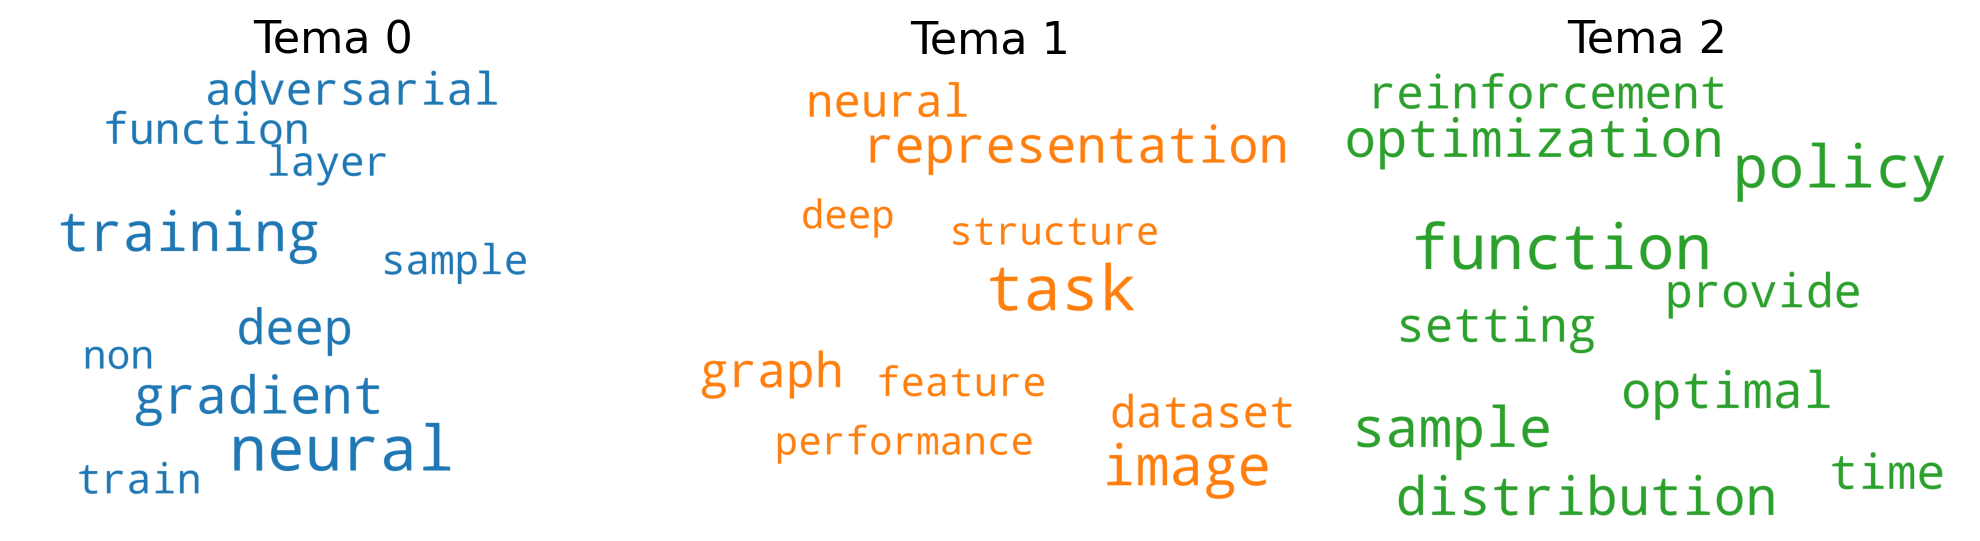

In [98]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.colors as mcolors

cols = [color for name, color in mcolors.TABLEAU_COLORS.items()]  # more colors: 'mcolors.XKCD_COLORS'

cloud = WordCloud(background_color='white',
                  width=2500,
                  height=1800,
                  max_words=20,
                  colormap='tab10',
                  color_func=lambda *args, **kwargs: cols[i],
                  prefer_horizontal=1.0)

topics = lda_model.show_topics(formatted=False,num_words=10)

fig, axes = plt.subplots(1, 3, figsize=(10,8), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):
    fig.add_subplot(ax)
    topic_words = dict(topics[i][1])
    cloud.generate_from_frequencies(topic_words, max_font_size=250)
    plt.gca().imshow(cloud)
    plt.gca().set_title('Tema ' + str(i), fontdict=dict(size=16))
    plt.gca().axis('off')


plt.subplots_adjust(wspace=0, hspace=0)
plt.axis('off')
plt.margins(x=0, y=0)
plt.tight_layout()
plt.show()

A fin de identificar la **temática de cada uno de los documentos**, debemos calcular la **proporción de cada tema por documento**. Recordemos que **no obtenemos una clasificación estricta** (salvo que asignemos cada documento al tema con más peso). En general se trabajará con el conjunto de pesos de cada tema por documento.

Vamos a ver cómo calcular esta representación:

In [99]:
#Elegimos un documento:
idx_document = 0

print(recent_nips.iloc[idx_document]['Title_abstract'])

for index, score in lda_model[corpus_bow[idx_document]]:
    print("\nScore: %f\t \n Tema: %r" %(score, lda_model.print_topic(index, 20)))

Compositional Plan Vectors Autonomous agents situated in real-world environments must be able to master large repertoires of skills.
While a single short skill can be learned quickly, it would be impractical to learn every task independently. Instead, the agent should share knowledge across behaviors such that each task can be learned efficiently, and such that the resulting model can generalize to new tasks, especially ones that are compositions or subsets of tasks seen previously.
A policy conditioned on a goal or demonstration has the potential to share knowledge between tasks if it sees enough diversity of inputs. However, these methods may not generalize to a more complex task at test time. We introduce compositional plan vectors (CPVs) to enable a policy to perform compositions of tasks without additional supervision. CPVs represent trajectories as the sum of the subtasks within them. We show that CPVs can be learned within a one-shot imitation learning framework without any addi

Finalmente, usando estas **proporciones de temas** de cada documento, podemos obtener una representación alternativa para cada documento. Con la siguiente función resumimos la proporción de temas para todos los artículos del dataset ...

In [100]:
# Vamos a pasar a una matriz las proporciones de temas por documento

temas_train = lda_model[corpus_bow]
print(type(temas_train))

<class 'gensim.interfaces.TransformedCorpus'>


Vemos que es un **corpus transformado por el modelo LDA**. Para trabajar con la **matriz de datos** necesitamos convertirlo a un **Numpy Array denso**.

**NOTA**: Hay que indicar el número de temas utilizado para fijar el número de columnas de la matriz. **OJO:** si se usa un número de temas distinto la función ``corpus2dense`` no produce ningún error, pero obviamente el resultado sería erróneo.

In [101]:
from gensim.matutils import corpus2dense

corpus_LDA_dense_train = corpus2dense(temas_train, num_terms=número_temas, num_docs=len(temas_train)).T

print("Este es el tamaño de la matriz resultante:")
print(corpus_LDA_dense_train.shape)
print("\nContiene {} documentos".format(corpus_LDA_dense_train.shape[0]))
print("Cada documento está representado por {} valores, los pesos de cada tema en LDA.".format(corpus_LDA_dense_train.shape[1]))

Este es el tamaño de la matriz resultante:
(1428, 3)

Contiene 1428 documentos
Cada documento está representado por 3 valores, los pesos de cada tema en LDA.


In [102]:
corpus_LDA_dense_train[0:10,:]

array([[0.        , 0.8801983 , 0.1158556 ],
       [0.05998964, 0.9362082 , 0.        ],
       [0.6786739 , 0.        , 0.31526217],
       [0.        , 0.6925146 , 0.3022941 ],
       [0.72901684, 0.2654889 , 0.        ],
       [0.        , 0.99159116, 0.        ],
       [0.0196923 , 0.        , 0.97392315],
       [0.4818016 , 0.        , 0.51276135],
       [0.9883796 , 0.        , 0.        ],
       [0.        , 0.        , 0.9855739 ]], dtype=float32)

Observamos que la expresión de cada documento como mezcla de temas tiene ahora bastantes valores nulos y en todo caso siempre pesos positivos, a diferencia de lo que ocurría en LSA.

En el ejemplo anterior hemos indicado que se identifiquen 3 temas, pero ese valor no tiene por qué ser el óptimo. A continuación vamos a ver qué técnicas se pueden utilizar para **elegir el número de temas** usando criterios objetivos y los datos disponibles para el entrenamiento.

# 7 - Selección del número de temas

Al tratarse de modelos no supervisados, no disponemos de una métrica unívoca para la validación de parámetros de un modelo de temas (típicamente el número de temas). En este [articulo](http://svn.aksw.org/papers/2015/WSDM_Topic_Evaluation/public.pdf) se hace un resumen muy completo de las distintas métricas en un modelo de temas que típicamente se utilizan de forma combinada. Por una parte, tenemos **métricas de ajuste** del modelo a datos de validación:

* **LL: log-likelihood**: dado un documento con palabras $\mathbf{w}_d$, log-probabilidad de ser una muestra del modelo LDA entrenado:

$$\log p(\mathbf{w}_d) = \log \int p(\theta_d)\prod_{k=1}^{K}p(\beta_k)\prod_{j=1}^{D_d} p(w_{jd}|\beta_{z_{jd}})p(z_{jd}|\theta_d)~d\beta_1\ldots d\beta_k d\theta_d d\mathbf{z}_d$$

* **LP: log_perplexity**: dado un conjunto de validación $\mathcal{D}_{\text {val}} =\left(\mathbf{w}_1,\ldots,\mathbf{w}_M\right)$, siendo $N_d$ el número de palabras del documento $d$, se define como

$$\text { perplexity }\left(\mathcal{D}_{\text {val}}\right)=\exp \left\{-\frac{\sum_{d=1}^{M} \log p\left(\mathbf{w}_{d}\right)}{\sum_{d=1}^{M} N_{d}}\right\}$$

$\quad$ A menor valor, mejor ajuste a los datos. **Nota:** `topic_model.log_perplexity` devuelve una cota inferior a $\sum_{d=1}^{M} \log p\left(\mathbf{w}_{d}\right)$, por tanto a mayor valor mejor ajuste.

Si bien estas métricas están relacionadas con el ajuste de los datos al modelo probabilístico de LDA, existen **métricas de coherencia** que se han demostrado **más correladas con un criterio manual** (una persona validando la interpretabilidad/coherencia de los temas encontrados). Estas métricas parten de tomar las $T$ palabras más relevantes por tema y promedia una medida de coherencia entre todos los posibles pares en este conjunto de $T$ palabras. A mayor valor, más coherencia interna en los temas:

* **UCI coherence score**: información mutua puntual (pointwise mutual information PMI) promedio entre los pares de palabras

$$C_{\mathrm{UCI}}=\frac{2}{T \cdot(T-1)} \sum_{i=1}^{T-1} \sum_{j=i+1}^{T} \operatorname{PMI}\left(w_{i}, w_{j}\right), \quad \operatorname{PMI}\left(w_{i}, w_{j}\right)=\log \frac{P\left(w_{i}, w_{j}\right)+\epsilon}{P\left(w_{i}\right) \cdot P\left(w_{j}\right)}$$

* **UMass coherence**: probabilidad condicional promedio entre los pares de palabras

$$C_{\mathrm{UMass}}=\frac{2}{T \cdot(T-1)} \sum_{i=2}^{T} \sum_{j=1}^{i-1} \log \frac{P\left(w_{i}, w_{j}\right)+\epsilon}{P\left(w_{j}\right)}$$

* Finalmente, existen varias métricas basadas en medir la distancia (e.g. distancia coseno) entre vectores de contexto asociados a cada una de las $T$ palabras. Una elección habitual del vector de contexto es utilizar PMI normalizada en palabras que aparecen en una ventana de $\pm5$ palabras. Para la palabra $w_i$ de las más relevantes del tema, construiremos el vector
$\mathbf{v}_i$ de dimensión igual al diccionario, de forma que el elemento $j$ del vector $\mathbf{v}_i$ asociado a la palabra $w_i$ se calcula como
$$v_{i j}=\operatorname{NPMI}\left(w_{i}, w_{j}\right)^{\gamma}=\left(\frac{\log \frac{P\left(w_{i}, w_{j}\right)+\epsilon}{P\left(w_{i}\right) \cdot P\left(w_{j}\right)}}{\log \left(P\left(w_{i}, w_{j}\right)+\epsilon\right)}\right)^{\gamma}, \qquad \gamma>0$$

Finalmente, dados los vectores contexto $\mathbf{v}_1,\ldots,\mathbf{v}_T$ calculamos la métrica de coherencia

$$C_{NPMI} = \frac{2}{T \cdot(T-1)} \sum_{i=1}^{T-1} \sum_{j=i+1}^{T} \text{dcos}(\mathbf{v}_i,\mathbf{v}_j)$$

Para el cálculo de las métricas anteriores, las probabilidades $P\left(w_{i}, w_{j}\right)$ y $P\left(w_{i}\right)$ se calculan a patir de una matriz de co-ocurrencias basada en una **ventana deslizante de tamaño $W$ sobre los textos del conjunto de validación**.


A continuación usaremos la clase clase [**``models.coherencemodel``**](https://radimrehurek.com/gensim/models/coherencemodel.html), que nos permite calcular las métricas anteriores de forma sencilla. A esta clase debemos pasarle los **documentos tokenizados**, es necesario el texto natural para el cálculo de la matriz de co-ocurrencias en una ventana deslizante.

A fin de elegit el valor óptimo de $K$, hay que entrenar modelos de tópicos con diferente número de temas y  elegir modelo que nos proporcione **mejores medidas de coherencia**. Los estimadores de coherencia no siempre muestran resultados intuitivos. En la práctica, **los estimadores que más se parecen a las intuiciones de un humano son las medidas UCI y NPMI**, que son las que utilizaremos aquí.

Los parámetros principales que requiere la función ``coherencemodel`` son los siguientes:

- **LDA_model**: modelo de temas pre-entrenado con el conjunto de entrenamiento.

- **documentos**: (lista de listas de strings), textos tokenizados.

- **BOW**: Corpus en formato BoW: iterable de lista de tuplas (indice, conteo).

- **Diccionario**:diccionario Gensim usado para crear el BOW.

- **coherencia**: medida de coherencia a utilizar (``u_mass``, ``c_v``, ``c_uci``, ``c_npmi``).



In [103]:
from gensim.models.coherencemodel import CoherenceModel

# Textos normalizados y tokenizados:
# corpus_norm

# BOW y tokenizados:
# corpus_bow

#### UCI
L_UCI = []

#### CNPMI
L_NPMI = []

topic_models = {}

### OJO, esta opción de barrido puede tardar hasta 40 minutos !!!!
# Exploramos soluciones con hasta K_max temas:
Kmax = 10
rango_K = np.arange(1, Kmax + 1, 1)

rango_K = [3,5, 7, 9, 10, 15, 20, 25, 30, 40, 50]

print("Explorando modelos con estos números de temas:")
print(rango_K)

for k in rango_K:
    print("Analizando modelo con {} temas...".format(k))
    topic_models[k] = gensim.models.LdaMulticore(corpus_bow, num_topics=k, id2word = D, passes=30)

    #### UCI
    cm = CoherenceModel(model=topic_models[k], texts=corpus_norm, dictionary=D, coherence='c_uci')
    L_UCI.append(cm.get_coherence())

    #### CNPMI
    cm = CoherenceModel(model=topic_models[k], texts=corpus_norm, dictionary=D, coherence='c_npmi')
    L_NPMI.append(cm.get_coherence())


Explorando modelos con estos números de temas:
[3, 5, 7, 9, 10, 15, 20, 25, 30, 40, 50]
Analizando modelo con 3 temas...
Analizando modelo con 5 temas...
Analizando modelo con 7 temas...
Analizando modelo con 9 temas...
Analizando modelo con 10 temas...
Analizando modelo con 15 temas...
Analizando modelo con 20 temas...
Analizando modelo con 25 temas...
Analizando modelo con 30 temas...
Analizando modelo con 40 temas...
Analizando modelo con 50 temas...


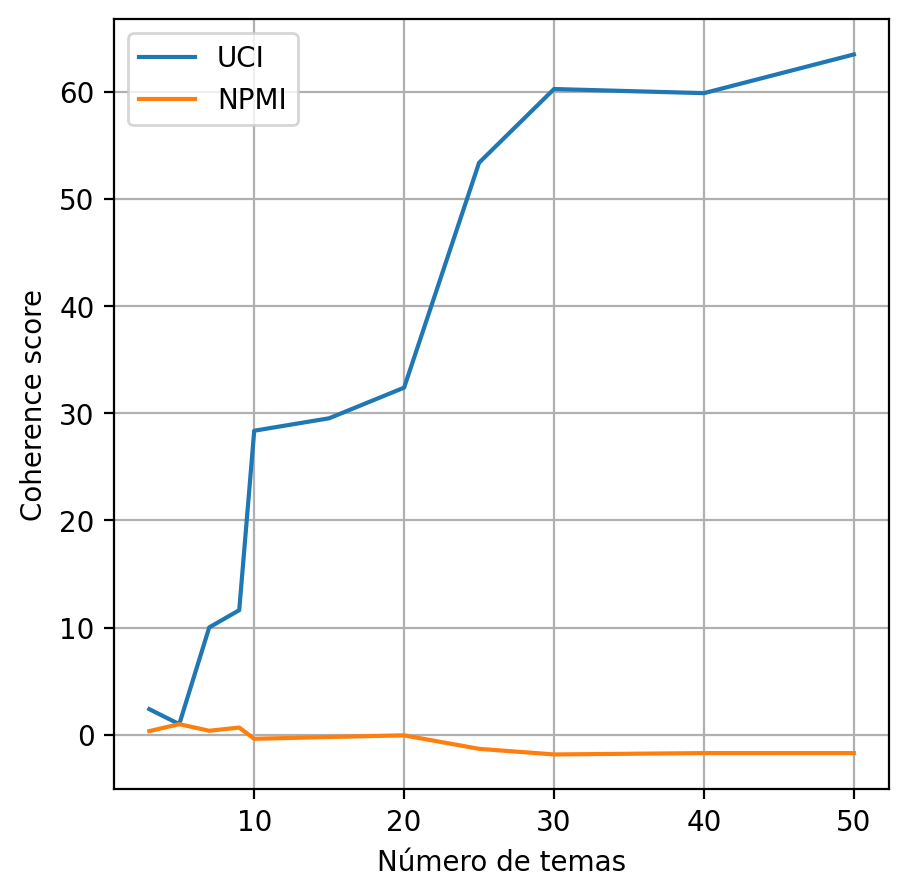

In [104]:
plt.figure(figsize=(5,5))
plt.plot(rango_K, L_UCI / np.max(L_UCI), label = "UCI")
plt.plot(rango_K, L_NPMI/ np.max(L_NPMI), label = "NPMI")
plt.ylabel('Coherence score')
plt.xlabel('Número de temas')
plt.legend()
plt.grid()

Vamos a visualizar directamente los resultados, pues la ejecución tarda bastantes minutos. Observamos que se alcanza un **máximo para 7 tópicos**, en ambas medidas de coherencia:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/Coherence_TM_UCI_NPMI.PNG' width=400 />
</center>



In [105]:
# Entrenamos el modelo de temas con 7 temas
best_topic_model = gensim.models.LdaMulticore(corpus_bow, num_topics=7, id2word = D, passes=30)

# 8 - Almacenamiento de modelos

Como los modelos de tópicos son **costosos de obtener**, especialmente si el entrenamiento se debe realizar utilizando corpus muy grandes, suele ser ventajoso almacenar dichos resultados para un uso posterior.

Podremos utilizar **``pickle``** para tal fin, o bien utilizar los métodos **``load``** y **``save``** proporcionados por el propio modelo LDA.

Comencemos por probar el almacenamiento con  **``pickle``**:

In [106]:
import pickle
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/ProcesadoLenguajeNatural/8_MaterialComplementario/'
filename = BASE_DIR + 'best_topic_model_Neurips.pkl'
print("Saving LDA model to {}".format(filename))
pickled_file = open(filename, 'wb')
pickle.dump(best_topic_model, pickled_file)
pickled_file.close()

Saving LDA model to /Volumes/Extreme Pro Particion 1TB/ProcesadoLenguajeNatural/8_MaterialComplementario/best_topic_model_Neurips.pkl


Vamos a comprobar que hemos almacenado correctamente el modelo, leyéndolo y comparando con el modelo original:

In [107]:
filename = BASE_DIR + 'best_topic_model_Neurips.pkl'
print("Loading LDA model from {}".format(filename))
pickled_file = open(filename, 'rb')
best_topic_model_loaded = pickle.load(pickled_file)
pickled_file.close()

import numpy as np

Mtopics_original = best_topic_model.get_topics()
Mtopics_loaded = best_topic_model_loaded.get_topics()

print("Diferencia entre ambos modelos = {}".format(np.linalg.norm(Mtopics_original - Mtopics_loaded)))


Loading LDA model from /Volumes/Extreme Pro Particion 1TB/ProcesadoLenguajeNatural/8_MaterialComplementario/best_topic_model_Neurips.pkl
Diferencia entre ambos modelos = 0.0


Vamos a almacenar y recuperar ahora el modelo directamente con las utilidades  **``load``** y **``save``** del propio modelo LDA. Le daremos una extensión ".lda" para diferenciarla del almacenamiento con pickle. Vemos que usando este método se generan varios ficheros correspondientes al modelo.

In [108]:
filename = BASE_DIR + 'best_topic_model_Neurips.lda'

print("Saving LDA model to {}".format(filename))
best_topic_model.save(filename)

Saving LDA model to /Volumes/Extreme Pro Particion 1TB/ProcesadoLenguajeNatural/8_MaterialComplementario/best_topic_model_Neurips.lda


Vamos a recuperar el modelo, asumiendo que partimos de un modelo vacío:

In [109]:
print("Loading LDA model from {} using gensim load function".format(filename))

best_topic_model_loaded_gensim = gensim.models.LdaMulticore.load(filename)

Mtopics_original = best_topic_model.get_topics()
Mtopics_loaded_gensim = best_topic_model_loaded_gensim.get_topics()

print("Diferencia entre ambos modelos = {}".format(np.linalg.norm(Mtopics_original - Mtopics_loaded_gensim)))

Loading LDA model from /Volumes/Extreme Pro Particion 1TB/ProcesadoLenguajeNatural/8_MaterialComplementario/best_topic_model_Neurips.lda using gensim load function
Diferencia entre ambos modelos = 0.0


# 9 -  Visualización del modelo de tópicos con pyLDAvis

Vamos a visualizar el mejor modelo encontrado con la librería [pyLDAvis](https://github.com/bmabey/pyLDAvis):

In [110]:
#!pip install pyldavis
#import pyLDAvis
pyLDAvis.enable_notebook()

#prepare(topic_term_dists, doc_topic_dists, doc_lengths, vocab, term_frequency, R=30, lambda_step=0.01, mds=js_PCoA, n_jobs=-1, plot_opts=None, sort_topics=True, start_index=1)
# topic_term_dists : array-like, shape (`n_topics`, `n_terms`) Matrix of topic-term probabilities. Where `n_terms` is `len(vocab)`.
# doc_topic_dists : array-like, shape (`n_docs`, `n_topics`) Matrix of document-topic probabilities.
# doc_lengths : array-like, shape `n_docs` The length of each document, i.e. the number of words in each document.
# vocab : array-like, shape `n_terms` List of all the words in the corpus used to train the model.
# term_frequency : array-like, shape `n_terms` The count of each particular term over the entire corpus. The ordering
# R : int The number of terms to display in the barcharts of the visualization. Default is 30. Recommended to be roughly between 10 and 50.


In [111]:
Ndocs = len(corpus_bow)
Ntemas = best_topic_model.num_topics
Nwords = len(D)
T = best_topic_model.get_topics()
print("LDA model trained with {} topics, {} docs and {} words".format(Ntemas, Ndocs, Nwords))
print(T.shape)


LDA model trained with 7 topics, 1428 docs and 1586 words
(7, 1586)


In [112]:
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()

# The pyLDAvis.gensim_models.prepare function takes the Gensim LDA model,
# the corpus in BoW format, and the Gensim dictionary.
# It automatically extracts the topic-term distributions, document-topic distributions,
# document lengths, vocabulary, and term frequencies.

# 'best_topic_model' is the trained LDA model with 7 topics.
# 'corpus_bow' is the corpus in bag-of-words format.
# 'D' is the Gensim dictionary.

data = pyLDAvis.gensim_models.prepare(best_topic_model, corpus_bow, D)
pyLDAvis.save_html(data, BASE_DIR + "LDAvis_best_model.html")
print("LDA model visualization saved as:" + BASE_DIR + "LDAvis_best_model.html")

LDA model visualization saved as:/Volumes/Extreme Pro Particion 1TB/ProcesadoLenguajeNatural/8_MaterialComplementario/LDAvis_best_model.html


Debemos abrir el fichero html generado en un navegador para acceder a la exploración interactiva del modelo:

<img src='http://www.tsc.uc3m.es/~navia/figures/pyLDAvis_html.png' width=800 />

La visualización de pyLDAvis nos ofrece la siguiente información:

* **Intertopic distance map (panel de la izquierda)** visualización 2D de los temas. El área por tema es proporcional al **número de palabras que pertenecen a cada tema** en nuestro corpus. Recordad que en el modelo generativo cada palabra se muestrea de un tema en particular, durante la inferencia LDA obtenemos el tema asociado a cada palabra.  Además, los circulos se dibujan en un espacio 2D usando el algoritmo [multidimensional scaling](https://en.wikipedia.org/wiki/Multidimensional_scaling), que proyecta la distribución de cada tema $\beta_k$, $k=1,\ldots,K$ en 2D **manteniendo aproximadamente las distancias entre puntos**.

* **Palabras más importantes del corpus**, definidas como aquellas que maximizan el siguiente *saliency score*:

$$s(w) = p(w) * \sum_{k=0}^{K} p(k|w) \log(\frac{ p(k|w)}{p(k)})$$

obsérvese que cada uno de los términos del sumatorio representan la divergencia KL entre la distribución a posteriori de los temas dada la palabra $w$ ($p(k|w)$) y la probabilidad a priori de los mismos ($p(k)$).

* **Palabras más relevantes por tema**. Si $\beta_{k,w}=p(w|k)$ es la probabilidad de la palabra $w$ en el tema $k$, se calcula su relevancia como

$$r(w,k|\lambda) = \lambda *\log(\beta_{k,w}) + (1-\lambda) \log(\frac{\beta_{k,w}}{p(w)})$$

donde $p(w)$ es la probabilidad de palabra en el corpus. Para $\lambda=1$ ordenamos las palabras según su probabilidad en el tema, para $\lambda=0$, penalizamos aquellas palabras más probables en el corpus. Esto puede ayudar a interpretar mejor cada tema al filtrar palabras que aparecen en varios temas.


# 10 - Ejercicios complementarios (opcional)

## Ejercicio:

El objetivo es identificar y mostrar el documento que mejor representa a cada uno de los temas. Para ello, para cada tema, localizaremos el documento con mayor peso en dicho tópico.

In [114]:
recent_nips.columns

Index(['source_id', 'year', 'title', 'abstract', 'full_text',
       'Title_abstract'],
      dtype='object')

In [116]:
# Para cada tema, encontrar el documento con mayor peso en ese tema
# Recalcular la matriz densa con el best_topic_model (7 temas)
corpus_LDA_best = best_topic_model[corpus_bow]
corpus_LDA_dense_train = gensim.matutils.corpus2dense(corpus_LDA_best, num_terms=best_topic_model.num_topics).T
print(f"Shape: {corpus_LDA_dense_train.shape}")  # Debería ser (1428, 7)

for topic_idx in range(best_topic_model.num_topics):
    # Obtener el índice del documento con mayor peso en este tema
    top_doc_idx = np.argmax(corpus_LDA_dense_train[:, topic_idx])
    top_doc_weight = corpus_LDA_dense_train[top_doc_idx, topic_idx]
    
    print(f"\n--- Tema {topic_idx} (peso: {top_doc_weight:.4f}) ---")
    print(f"Documento índice: {top_doc_idx}")
    print(f"Título: {recent_nips.iloc[top_doc_idx]['title']}")
print(f"Texto (primeros 500 chars): {recent_nips.iloc[top_doc_idx]['abstract'][:500]}")

Shape: (1428, 7)

--- Tema 0 (peso: 0.9918) ---
Documento índice: 558
Título: Keeping Your Distance: Solving Sparse Reward Tasks Using Self-Balancing Shaped Rewards

--- Tema 1 (peso: 0.9940) ---
Documento índice: 827
Título: Dimensionality reduction: theoretical perspective on practical measures

--- Tema 2 (peso: 0.9936) ---
Documento índice: 531
Título: Universality and individuality in neural dynamics across large populations of recurrent networks

--- Tema 3 (peso: 0.9949) ---
Documento índice: 260
Título: The Step Decay Schedule: A Near Optimal, Geometrically Decaying Learning Rate Procedure For Least Squares

--- Tema 4 (peso: 0.9940) ---
Documento índice: 342
Título: Differentially Private Distributed Data Summarization under Covariate Shift

--- Tema 5 (peso: 0.9929) ---
Documento índice: 853
Título: The Point Where Reality Meets Fantasy: Mixed Adversarial Generators for Image Splice Detection

--- Tema 6 (peso: 0.9920) ---
Documento índice: 26
Título: Hyperbolic Graph Convolu

## Ejercicio:

Vamos a visualizar los temas y las palabras en un plano 2D:

- represente cada uno de los temas en un espacio de palabras,

y cada uno de los documentos en un espacio de temas.

Para ello debemos reducir a 2 la dimensión a de los espacios usando **PCA (Principal Component Analysis)**. Utilice la librería **PCA** disponible en **``sklearn.decomposition``**.

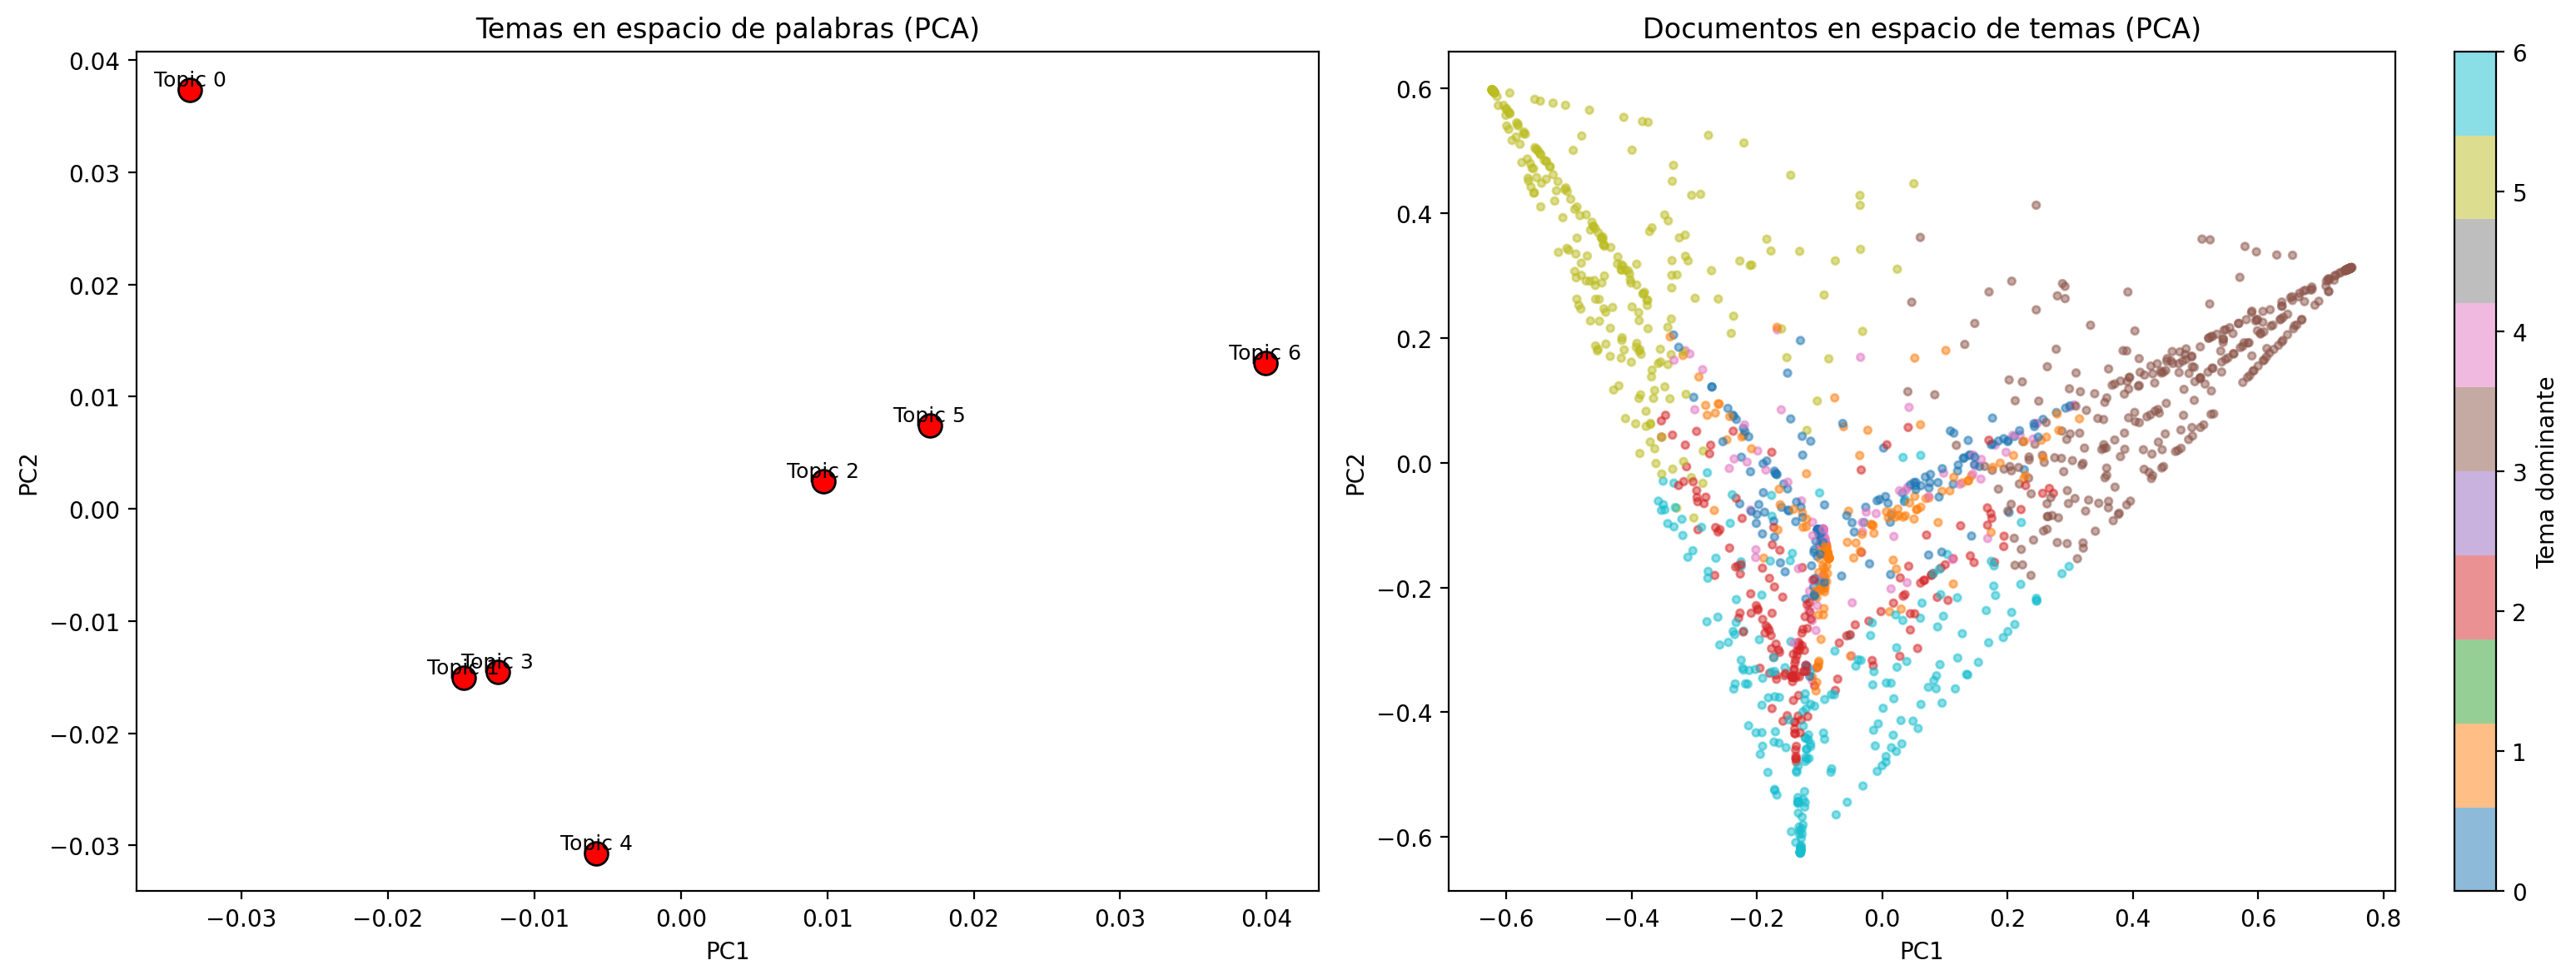

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

topic_word_matrix = best_topic_model.get_topics()  # (7, 1586)
pca_topics = PCA(n_components=2)
topics_2d = pca_topics.fit_transform(topic_word_matrix)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(topics_2d[:, 0], topics_2d[:, 1], s=100, c='red', edgecolors='black')
for i, (x, y) in enumerate(topics_2d):
    axes[0].annotate(f'Topic {i}', (x, y), fontsize=9, ha='center', va='bottom')
axes[0].set_title('Temas en espacio de palabras (PCA)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# 2) Documentos en espacio de temas
pca_docs = PCA(n_components=2)
docs_2d = pca_docs.fit_transform(corpus_LDA_dense_train)  # (1428, 7) → (1428, 2)

dominant_topic = np.argmax(corpus_LDA_dense_train, axis=1)

scatter = axes[1].scatter(docs_2d[:, 0], docs_2d[:, 1], c=dominant_topic,
                          cmap='tab10', alpha=0.5, s=10)
axes[1].set_title('Documentos en espacio de temas (PCA)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[1], label='Tema dominante')

plt.tight_layout()
plt.show()